In [1]:
import os; os.environ['WORKDIR'] = "/home/choij/workspace/ChargedHiggsAnalysis"
import sys; sys.path.insert(0, os.environ['WORKDIR'])
import numpy as np
import torch

from libPython.Preprocessor import evt_to_graph
from libPython.MLTools import ParticleNet
from libPython.Management import predict_proba

from libPython.DataFormat import get_muons, get_electrons, get_jets, Particle
from libPython.Selection import pass_baseline, select
from libPython.HistTools import HistogramWriter
from ROOT import TCanvas
from ROOT import TFile
from ROOT import TH1D

Welcome to JupyROOT 6.26/06


In [2]:
# load files and models
MASSPOINT = "MHc-130_MA-90"
BACKGROUND = "TTLL_powheg"
ERA = "2018"
MA = MASSPOINT.split("_")[1]
MA = int(MA.split("-")[1])
print(MA)

f_sig = TFile.Open(f"{os.environ['WORKDIR']}/SelectorOutput/{ERA}/Skim3Mu__/Selector_TTToHcToWAToMuMu_{MASSPOINT}.root")
f_bkg = TFile.Open(f"{os.environ['WORKDIR']}/SelectorOutput/{ERA}/Skim3Mu__/Selector_{BACKGROUND}.root")

# load model
OPTIM = "Adam"
InitLR = 0.01
SCHEDULER = "StepLR"
model_path = f"{os.environ['WORKDIR']}/models/pilot/{MASSPOINT}_vs_{BACKGROUND}/ParticleNet_{OPTIM}_initLR-{str(InitLR).replace('.', 'p')}_{SCHEDULER}.pt"
model = ParticleNet(num_features=9, num_classes=2, hidden_channels=128)
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

writer = HistogramWriter(outfile=f"{os.environ['WORKDIR']}/triLepRegion/test.root")

90


In [3]:
def getScore(model, objects):
    model.eval()
    node_list = []
    for obj in objects:
        node_list.append([obj.Pt(),
                          obj.Eta(),
                          obj.Phi(),
                          obj.M(),
                          obj.Charge(),
                          obj.IsMuon(),
                          obj.IsElectron(),
                          obj.IsJet(),
                          obj.BtagScore()])
    data = evt_to_graph(node_list, y=None, k=4)
    return predict_proba(model, data.x, data.edge_index)

In [4]:
def makeACand(muons):
    ACand = Particle(0., 0., 0., 0.)
    xACand = Particle(0., 0., 0., 0.)
    # make pairs
    if abs(muons[0].Charge() + muons[1].Charge()) == 2:
        pair1 = muons[0] + muons[2]
        pair2 = muons[1] + muons[2]
    elif abs(muons[0].Charge() + muons[2].Charge()) == 2:
        pair1 = muons[0] + muons[1]
        pair2 = muons[1] + muons[2]
    else:   # 1 == 2
        pair1 = muons[0] + muons[1]
        pair2 = muons[0] + muons[2]
        
    if abs(pair1.M() - MA) < abs(pair2.M() - MA):
        ACand, xACand = pair1, pair2
    else:
        ACand, xACand = pair2, pair1
    return (ACand, xACand)

In [5]:
# prepare array to evaluate correlation
arrScore = []
arrACand = []

for evt in f_sig.Events:
    muons = get_muons(evt)
    electrons = get_electrons(evt)
    jets, bjets = get_jets(evt)
    METv = Particle(evt.METvPt, 0., evt.METvPhi, 0.)
    weight = evt.GenWeight
    
    #if not pass_baseline("3Mu", evt, muons, electrons, jets ,bjets, "loose"):
    #    continue
    region = select("3Mu", evt, muons, electrons, jets, bjets, "tight")
    if region != "SignalRegion":
        continue
    
    objects = muons+electrons+jets
    objects.append(METv)
    score = getScore(model, objects)
    ACand, xACand = makeACand(muons)
    
    arrScore.append(score)
    arrACand.append(abs(ACand.M() - MA))
    
    writer.fill_hist("signal/score", score, weight, 100, 0., 1.)
    writer.fill_object("signal/ACand", ACand, weight)
    writer.fill_object("signal/xACand", xACand, weight)
    
    if score > 0.2:
        writer.fill_object("signal/score_above_0p2/ACand", ACand, weight)
    if score > 0.4:
        writer.fill_object("signal/score_above_0p4/ACand", ACand, weight)
    if score > 0.6:
        writer.fill_object("signal/score_above_0p6/ACand", ACand, weight)
    if score > 0.8:
        writer.fill_object("signal/score_above_0p8/ACand", ACand, weight)
        
f_sig.Close()

arrScore = np.array(arrScore)
arrACand = np.array(arrACand)

print(np.corrcoef(arrScore, arrACand))

[[ 1.         -0.05253052]
 [-0.05253052  1.        ]]


In [6]:
# prepare array to evaluate correlation
arrScore = []
arrACand = []

for evt in f_bkg.Events:
    muons = get_muons(evt)
    electrons = get_electrons(evt)
    jets, bjets = get_jets(evt)
    METv = Particle(evt.METvPt, 0., evt.METvPhi, 0.)
    weight = evt.GenWeight
    
    #if not pass_baseline("3Mu", evt, muons, electrons, jets ,bjets, "loose"):
    #    continue
    region = select("3Mu", evt, muons, electrons, jets, bjets, "tight")
    if region != "SignalRegion":
        continue
    
    objects = muons+electrons+jets
    objects.append(METv)
    score = getScore(model, objects)
    ACand, xACand = makeACand(muons)
    
    arrScore.append(score)
    arrACand.append(abs(ACand.M() - MA))
    writer.fill_hist("background/score", score, weight, 100, 0., 1.)
    writer.fill_object("background/ACand", ACand, weight)
    writer.fill_object("background/xACand", xACand, weight)
    
    if score > 0.2:
        writer.fill_object("background/score_above_0p2/ACand", ACand, weight)
    if score > 0.4:
        writer.fill_object("background/score_above_0p4/ACand", ACand, weight)
    if score > 0.6:
        writer.fill_object("background/score_above_0p6/ACand", ACand, weight)
    if score > 0.8:
        writer.fill_object("background/score_above_0p8/ACand", ACand, weight)
f_bkg.Close()
writer.close()

arrScore = np.array(arrScore)
arrACand = np.array(arrACand)

print(np.corrcoef(arrScore, arrACand))

Saving histograms in /home/choij/workspace/ChargedHiggsAnalysis/triLepRegion/test.root...
[[ 1.         -0.07395029]
 [-0.07395029  1.        ]]


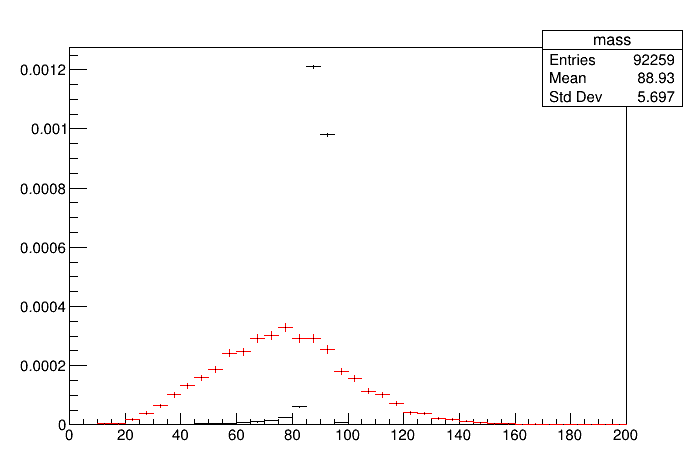

In [7]:
from ROOT import TCanvas, TFile

f = TFile.Open("../test.root")
h_sig = f.Get("signal/ACand/mass"); h_sig.SetDirectory(0)
h_bkg = f.Get("background/ACand/mass"); h_bkg.SetDirectory(0)

h_sig.Rebin(5)
h_bkg.Rebin(5)
h_sig.GetXaxis().SetRangeUser(0., 200.)
h_bkg.GetXaxis().SetRangeUser(0., 200.)

h_sig.SetLineColor(1)
h_bkg.SetLineColor(2)

c = TCanvas()
c.cd()
h_sig.Draw()
h_bkg.Draw("same")
c.Draw()
f.Close()

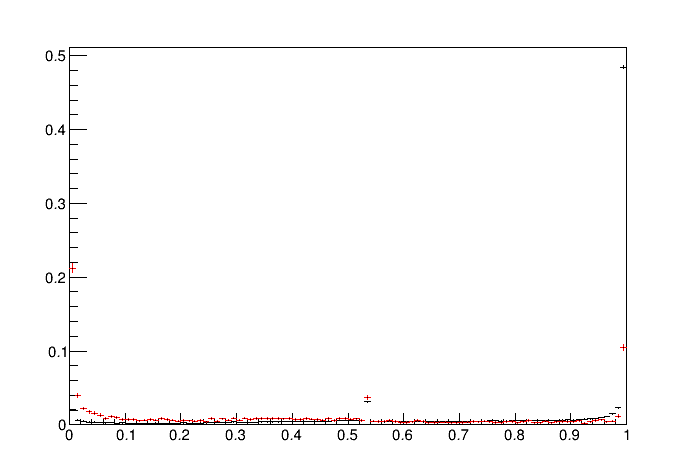

In [10]:
f = TFile.Open("../test.root")
h_sig = f.Get("signal/score"); h_sig.SetDirectory(0); h_sig.SetStats(0)
h_bkg = f.Get("background/score"); h_bkg.SetDirectory(0)

h_sig.Scale(1./h_sig.Integral())
h_bkg.Scale(1./h_bkg.Integral())

h_sig.SetLineColor(1)
h_bkg.SetLineColor(2)

c = TCanvas()
c.cd()
h_sig.Draw()
h_bkg.Draw("same")
c.Draw()
f.Close()

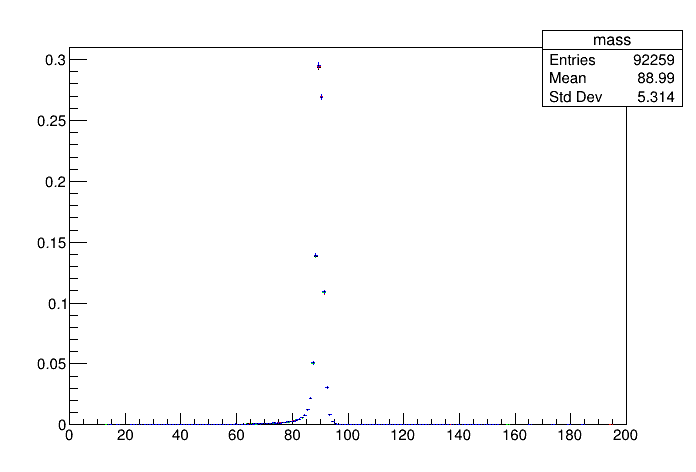

In [9]:
f = TFile.Open("../test.root")
h_sig = f.Get("signal/ACand/mass"); h_sig.SetDirectory(0)
h_0p2 = f.Get("signal/score_above_0p2/ACand/mass"); h_0p2.SetDirectory(0)
h_0p4 = f.Get("signal/score_above_0p4/ACand/mass"); h_0p4.SetDirectory(0)
h_0p6 = f.Get("signal/score_above_0p6/ACand/mass"); h_0p6.SetDirectory(0)

#h_sig.Rebin(5)
#h_0p2.Rebin(5)
#h_0p4.Rebin(5)
#h_0p6.Rebin(5)

h_sig.Scale(1./h_sig.Integral())
h_0p2.Scale(1./h_0p2.Integral())
h_0p4.Scale(1./h_0p4.Integral())
h_0p6.Scale(1./h_0p6.Integral())

h_sig.GetXaxis().SetRangeUser(0., 200.)
h_sig.SetLineColor(1)
h_0p2.SetLineColor(2)
h_0p4.SetLineColor(3)
h_0p6.SetLineColor(4)

c = TCanvas()
c.cd()
h_sig.Draw()
h_0p2.Draw("same")
h_0p4.Draw("same")
h_0p6.Draw("same")
c.Draw()
f.Close()